In [1]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
import corner
import matplotlib.lines as mlines

# Make sure this import matches your local module structure
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference, run_dspl_inference_joint, DSPLLikelihood
from pdspl_utils.plotting import plot_dspl_corner

POSTERIOR_DIRECTORY = '../data/posteriors/forecast_w0waCDM_fixed_scatter'
FIGURE_DIRECTORY = '../figures/forecasts/w0waCDM_fixed_scatter'

In [2]:
## Prepare Datasets for the Forecast

# Load the pdspl_samples object
with open('../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

In [3]:
# --- 2. INITIALIZE SCENARIOS ---
scenarios = {}

redshift_errors_rel = {
    'DSPL': 0.0001, # spec-z
    'lsst_y1': 0.03, # photo-z
    'lsst_y10': 0.03, # photo-z
    'lsst_4most_spec-z': 0.0001, # spec-z
    'lsst_4most_spec-z_sigma_v': 0.0001, # spec-z
}

# Populate PDSPL scenarios from pickle
for key in pdspl_samples.keys():
    scenarios[key] = {
        'name': f"PDSPL ({pdspl_samples[key]['name']})",
        'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 2000, 
        'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
        'color': pdspl_samples[key]['color'],
        'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
        'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
        'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        'redshift_error_rel': redshift_errors_rel[key],
        'backend_path': POSTERIOR_DIRECTORY + f"/{key}.h5"
    }

# Append the custom synthetic DSPL scenario
scenarios['DSPL'] = {
    'name': 'DSPL (500 lenses)',
    'down_sampling': 1,
    'num_lenses': 500,
    'color': '#1f77b4',
    'sigma_beta': 0.00, 
    'redshift_error_rel': redshift_errors_rel['DSPL'],
    'backend_path': POSTERIOR_DIRECTORY + f"/DSPL.h5"
}

In [4]:
# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios.keys():
    sc = scenarios[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []
    
    if key == 'DSPL':
        # Synthetic generation for pure DSPL
        for _ in range(num_samples):
            z_lens = np.random.normal(loc=0.5, scale=0.1)
            z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
            z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_intrinsic=sc['sigma_beta'], 
                sigma_meas_rel=sigma_meas_rel,
                dissimilarity=0.0,
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true,
                redshift_error_rel=sc['redshift_error_rel']
            ))
    else:
        # Generation from PDSPL tables
        pairs_table = sc['pairs_table']
        pairs_table_with_errors = sc['pairs_table_with_errors']
        coeffs = sc['coeffs']
        random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
        
        for i in random_indices:
            z_lens = pairs_table["z_D"][i]
            z1 = pairs_table["z_S1"][i]
            z2 = pairs_table["z_S2"][i]
            
            dissimilarity = pairs_table_with_errors['dissimilarity'][i]
            sigma_beta_intrinsic = np.polyval(coeffs, dissimilarity)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_intrinsic=sigma_beta_intrinsic,
                sigma_meas_rel=sigma_meas_rel,
                dissimilarity=dissimilarity,
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true, 
                redshift_error_rel=sc['redshift_error_rel']
            ))
            
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

original_keys = list(scenarios.keys())
print("\nOriginal Keys:", original_keys)

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                              | 2000       | GENERATED
PDSPL (LSST Y10)                                             | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$))                               | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))             | 2000       | GENERATED
DSPL (500 lenses)                                            | 500        | GENERATED

Original Keys: ['lsst_y1', 'lsst_y10', 'lsst_4most_spec-z', 'lsst_4most_spec-z_sigma_v', 'DSPL']


# Run the Forecast Inference

## Individual Forecasts

### a. Uniform Prior Forecasts

In [5]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers (Uniform Prior) ---")

param_labels = None 

for key in scenarios.keys():
    sc = scenarios[key]
    
    if 'kwargs_list' not in sc: continue 
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    # Isolate scatter coefficients to freeze them in the MCMC
    if key == 'DSPL':
        c0, c1, c2 = sc['sigma_beta'], 0.0, 0.0
    else:
        coeffs = sc.get('coeffs', [0.0])
        c0, c1, c2 = 0.0, 0.0, 0.0
        if len(coeffs) == 1: c0 = coeffs[0]
        elif len(coeffs) == 2: c1, c0 = coeffs
        elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]
    
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc['beta_c0'] = c0
    fixed_params_sc['beta_c1'] = c1
    fixed_params_sc['beta_c2'] = c2
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000,
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers (Uniform Prior) ---

Running Inference for: PDSPL (LSST Y1)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [09:57<00:00,  3.35it/s]


PDSPL (LSST Y1) | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:17<00:00,  3.24it/s]


PDSPL (LSST Y10) | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...

PDSPL (4MOST ($z^{\rm spec}$)) | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [07:27<00:00,  4.47it/s]


PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) | INFERENCE COMPLETE

Running Inference for: DSPL (500 lenses)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [04:07<00:00,  8.08it/s]


DSPL (500 lenses) | INFERENCE COMPLETE


### b. Gaussian Omega_m Prior Forecasts


In [10]:
# --- 1. INFERENCE SETTINGS ---
my_priors_om = my_priors.copy()
my_priors_om['om'] = ('gaussian', 0.3, 0.05)

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---")

for key in original_keys:
    key_with_prior = key + '_om_prior'
    scenarios[key_with_prior] = scenarios[key].copy()
    scenarios[key_with_prior]['name'] += ' + $\\Omega_m$ Prior'
    scenarios[key_with_prior]['backend_path'] = POSTERIOR_DIRECTORY + f"/{key_with_prior}.h5"

for key in original_keys:
    key_with_prior = key + '_om_prior'
    sc = scenarios[key_with_prior]
    
    if 'kwargs_list' not in sc: continue 
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    if key == 'DSPL':
        c0, c1, c2 = sc['sigma_beta'], 0.0, 0.0
    else:
        coeffs = sc.get('coeffs', [0.0])
        c0, c1, c2 = 0.0, 0.0, 0.0
        if len(coeffs) == 1: c0 = coeffs[0]
        elif len(coeffs) == 2: c1, c0 = coeffs
        elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]
    
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc['beta_c0'] = c0
    fixed_params_sc['beta_c1'] = c1
    fixed_params_sc['beta_c2'] = c2
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors_om,
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---

Running Inference for: PDSPL (LSST Y1) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:26<00:00,  3.19it/s]


PDSPL (LSST Y1) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:29<00:00,  3.18it/s]


PDSPL (LSST Y10) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...

PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [08:27<00:00,  3.94it/s]


PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: DSPL (500 lenses) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [04:29<00:00,  7.42it/s]

DSPL (500 lenses) + $\Omega_m$ Prior | INFERENCE COMPLETE


# Plotting the Forecast Results

In [ ]:
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_ranges = [
    (0, 1),            # om
    (-2, 0),           # w0
    (-3, 3),           # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.10),       # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
    (0.12, 0.20),      # gamma_sigma
]

###  a. All Scenarios Corner Plot -- Uniform Priors

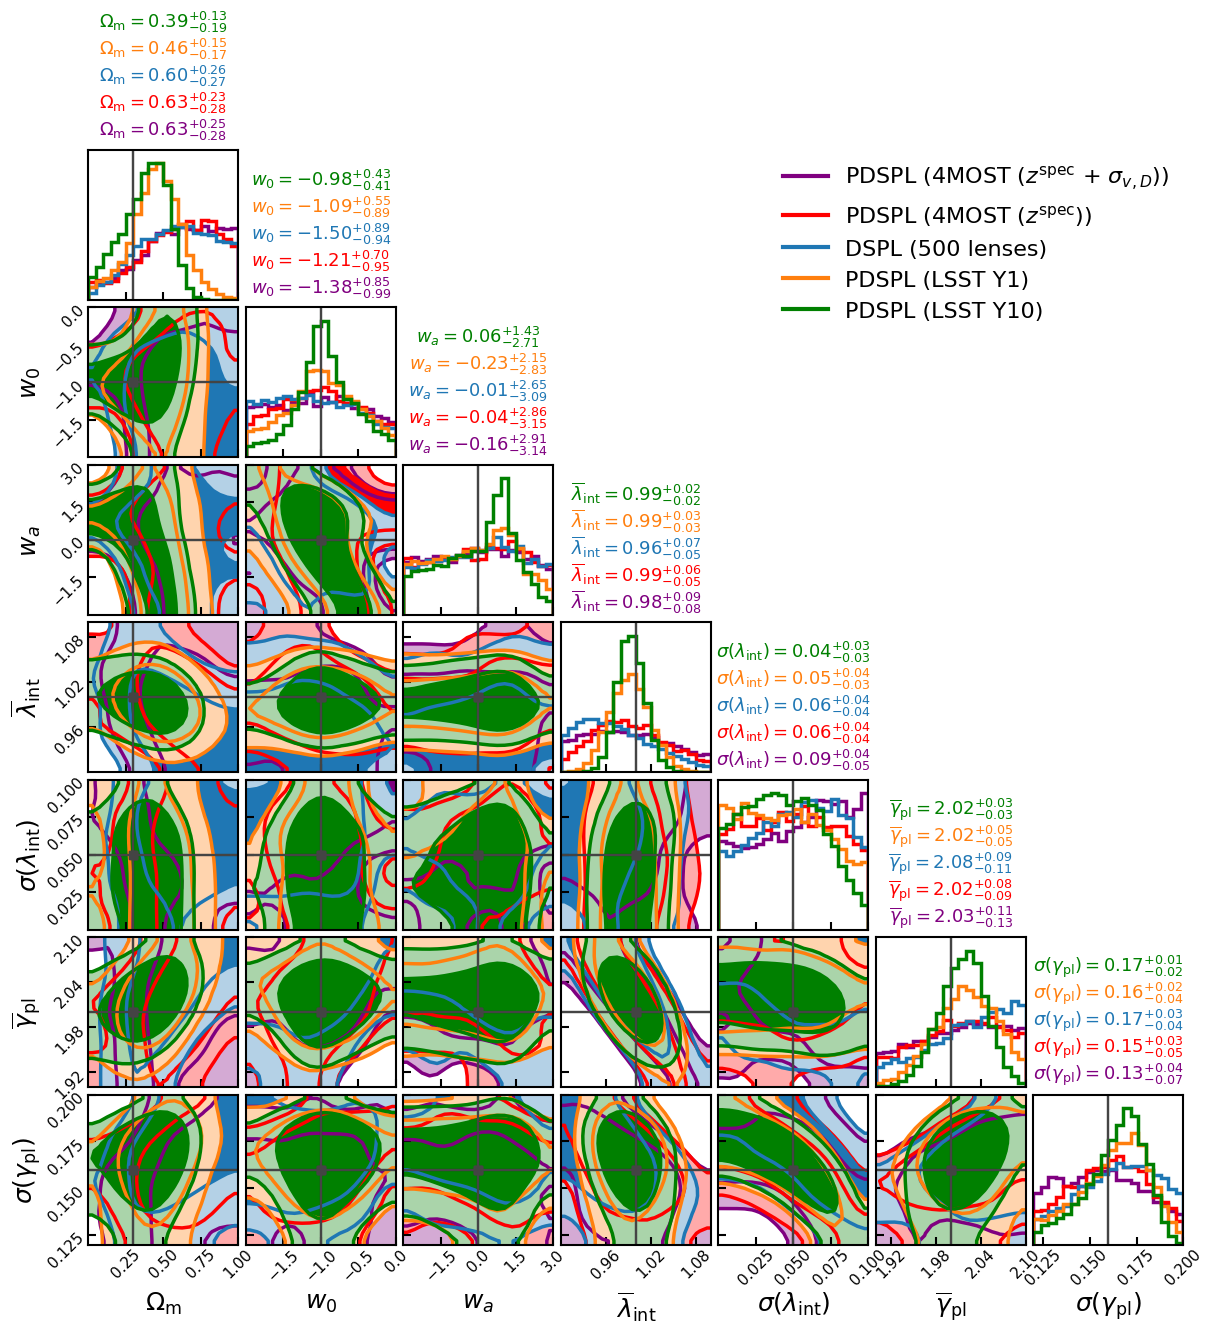

In [ ]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v', 
    'lsst_4most_spec-z', 
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot, 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Scatter Plot -- Uniform Priors

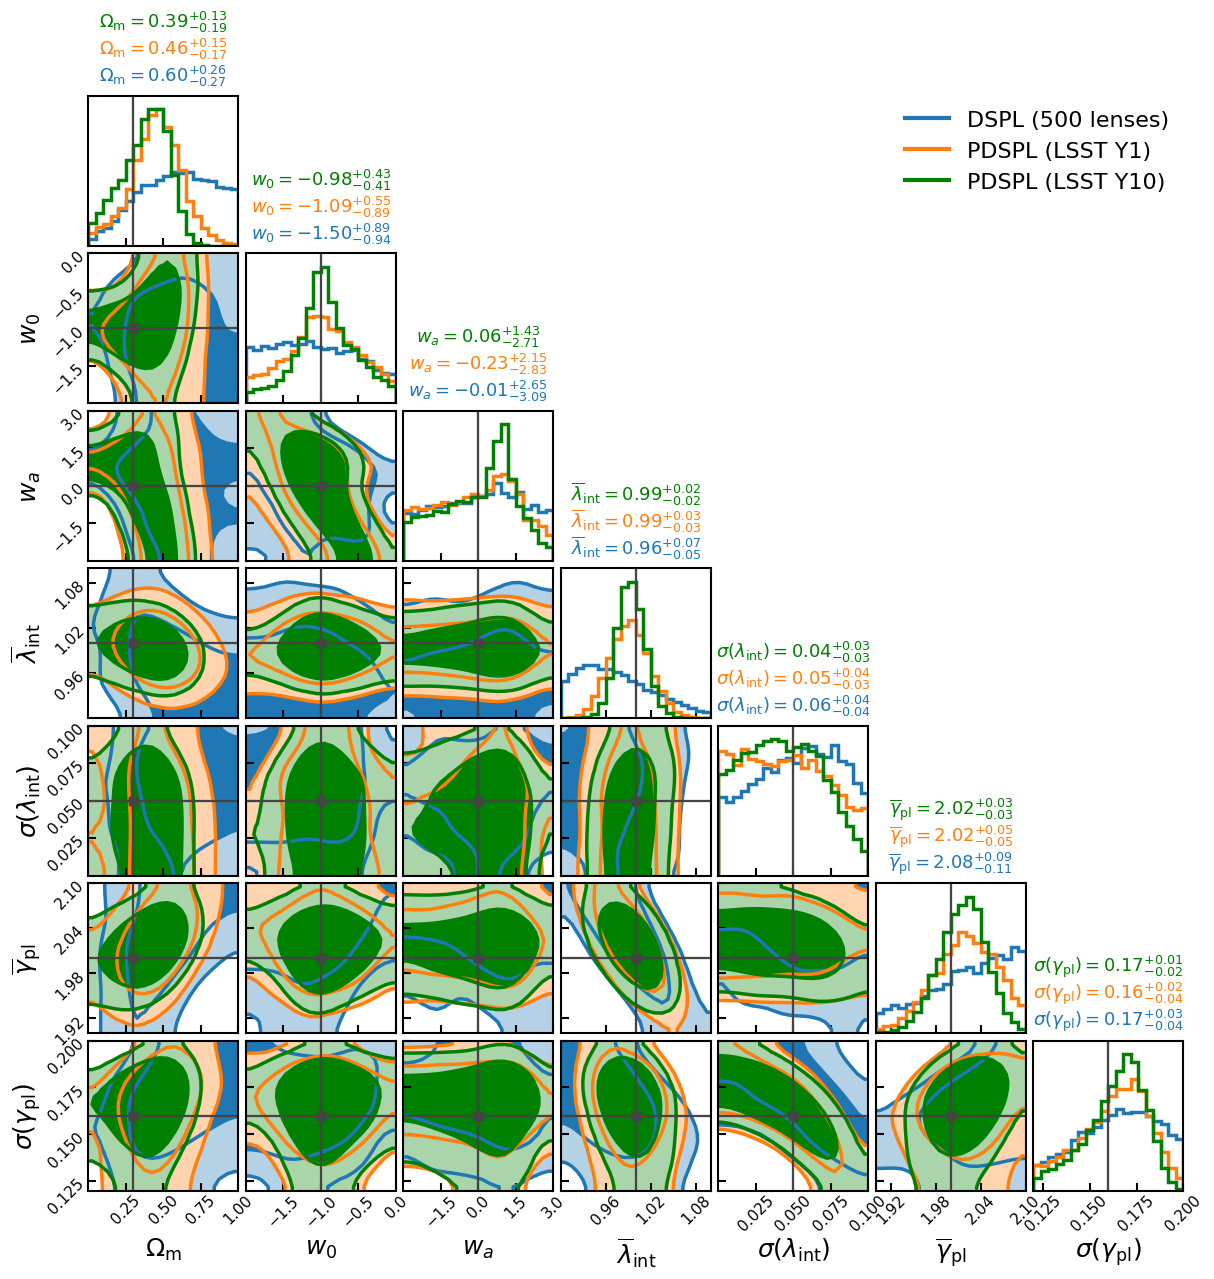

In [ ]:
scenarios_to_plot = [
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  c. All Scenarios Corner Plot -- $\Omega_m$ Prior

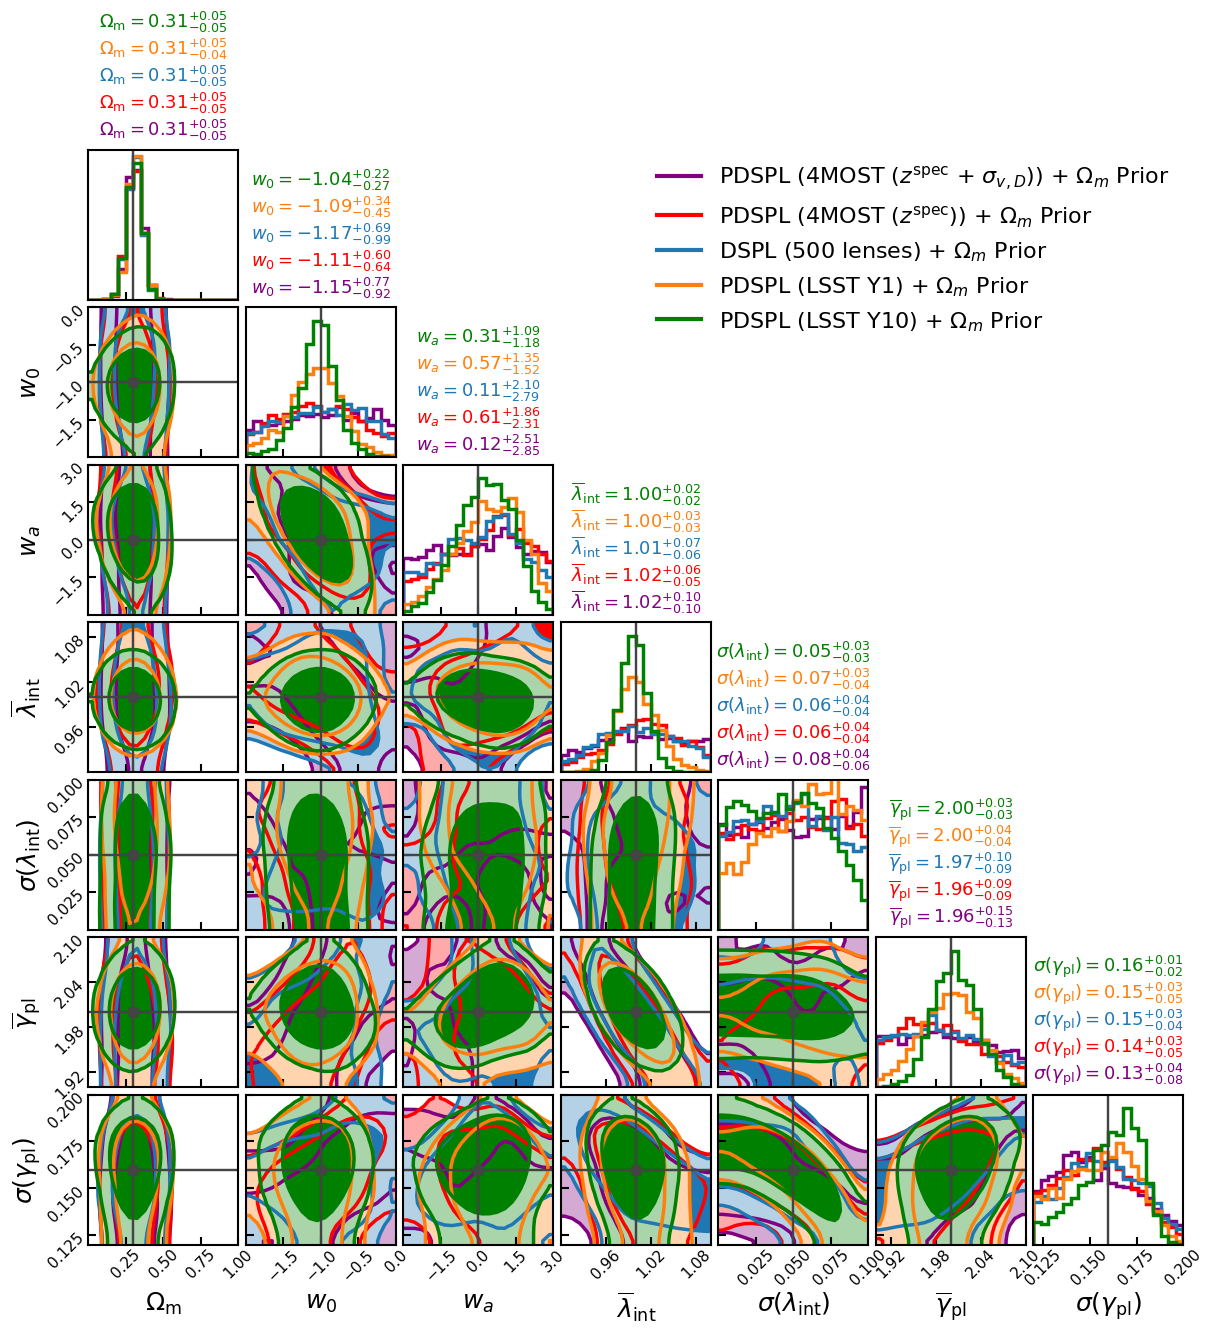

In [ ]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v_om_prior',
    'lsst_4most_spec-z_om_prior', 
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  d. DSPL, LSST Y1, and LSST Y10 Corner Plot -- $\Omega_m$ Prior

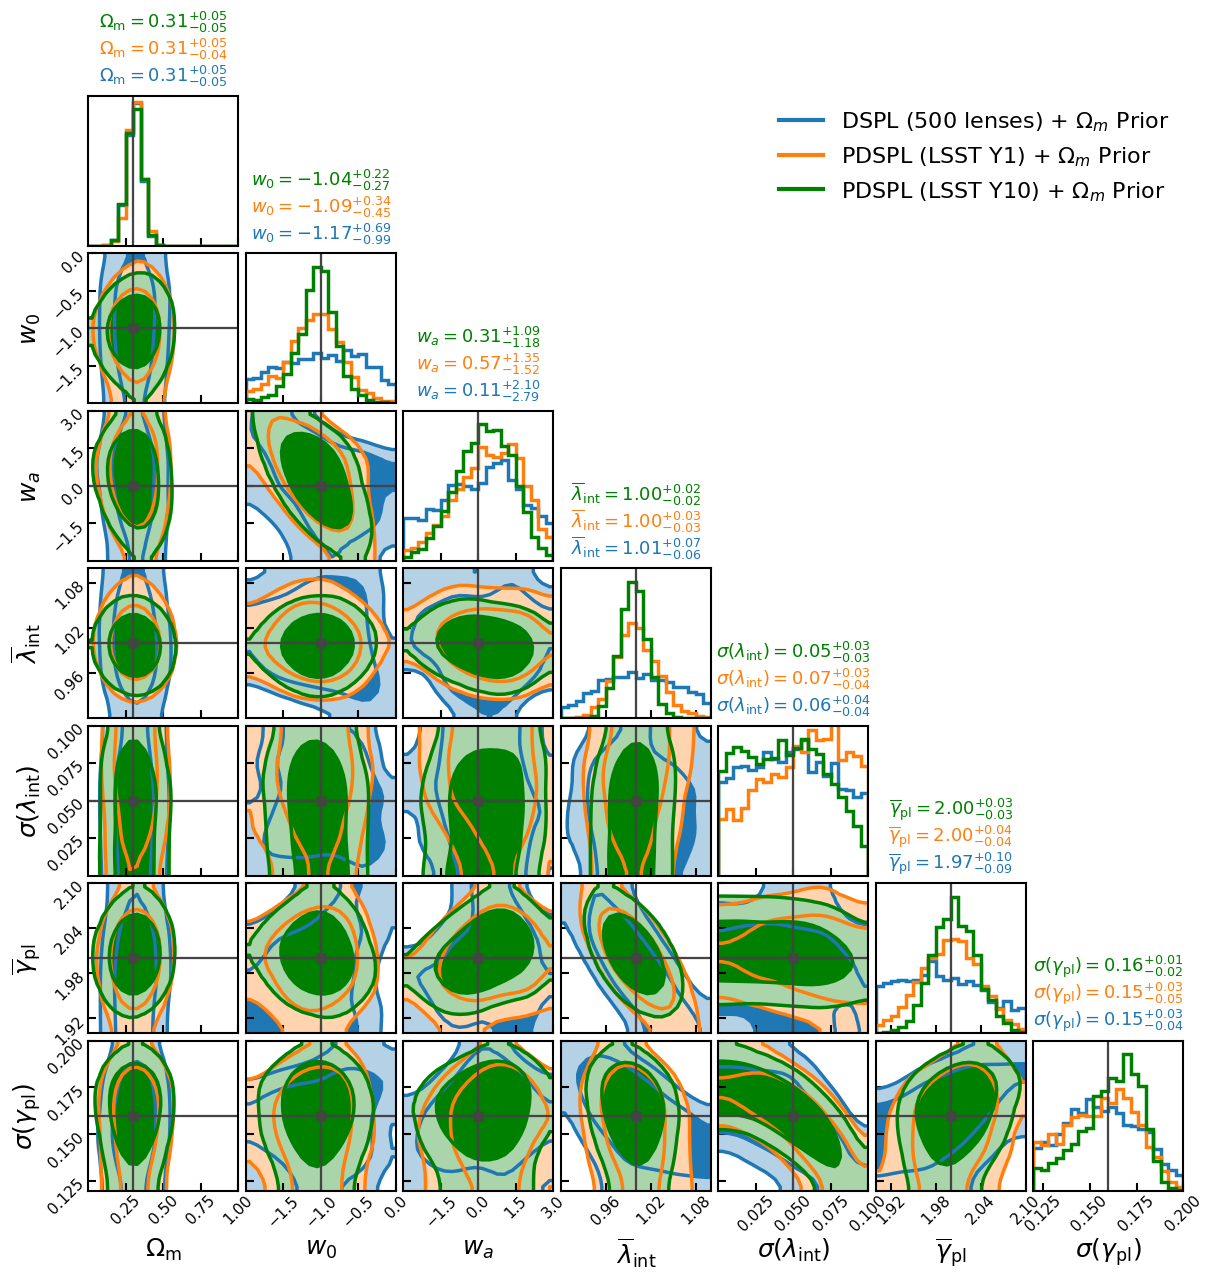

In [ ]:
scenarios_to_plot = [
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  e. LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

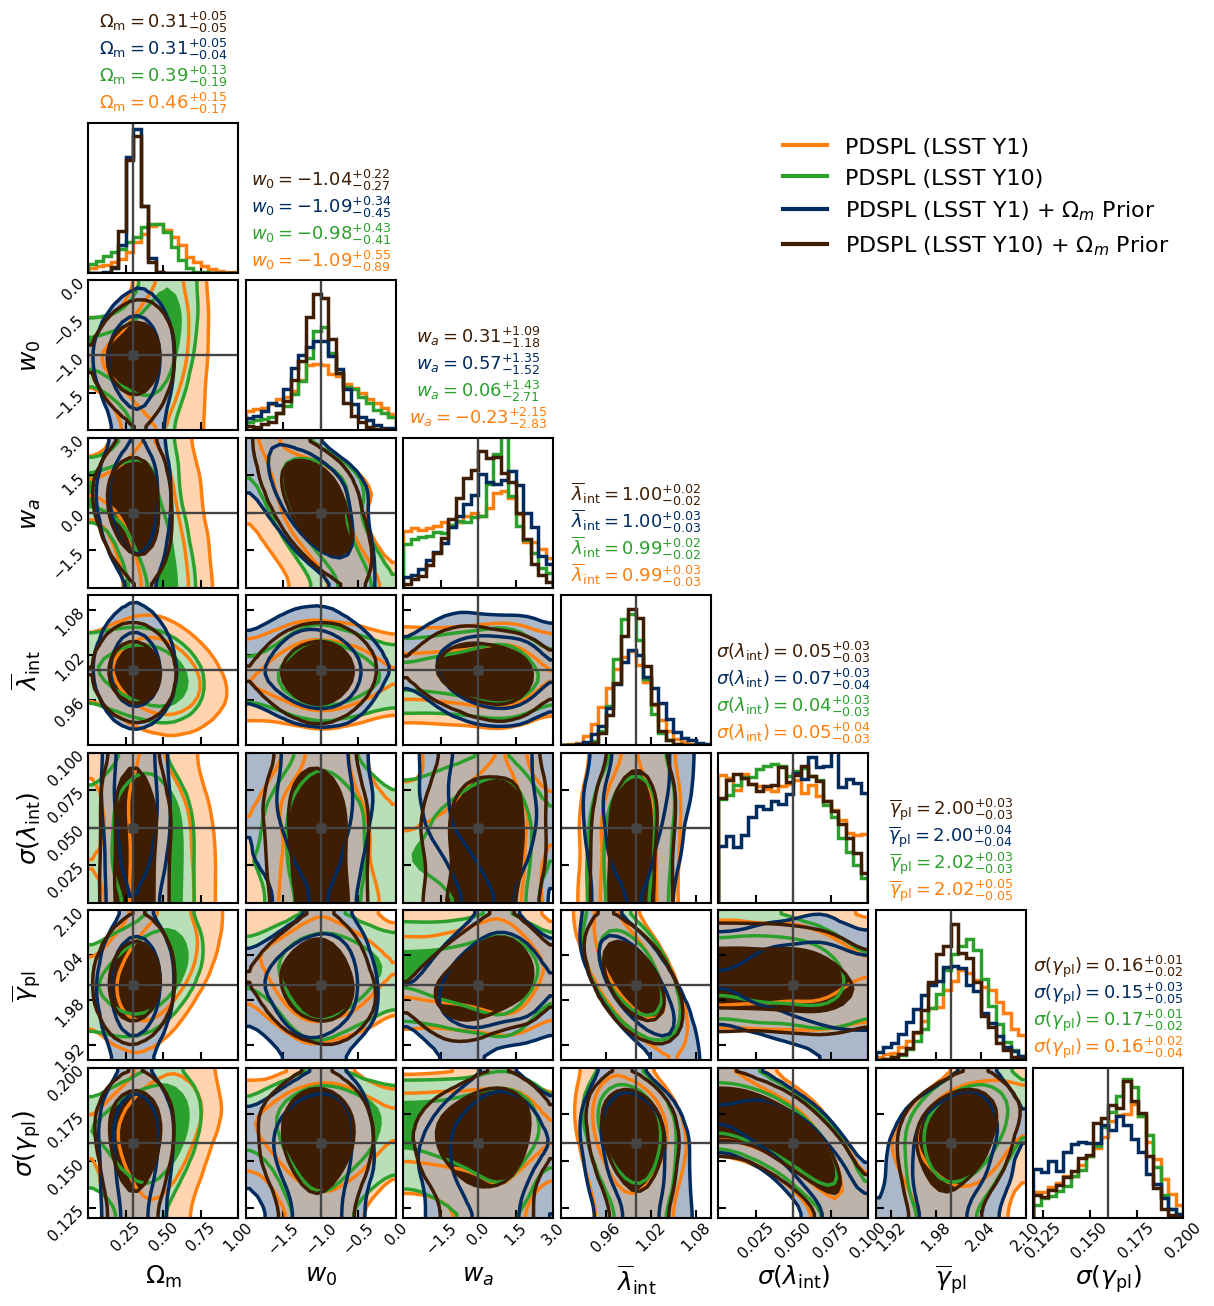

In [ ]:
scenarios_to_plot = [
    'lsst_y1',
    'lsst_y10',
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    'lsst_y1_om_prior': "#002B5F",
    'lsst_y10_om_prior': "#3e1d03"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

###  f. LSST Y10 vs DSPL Corner Plot -- With and Without $\Omega_m$ Prior

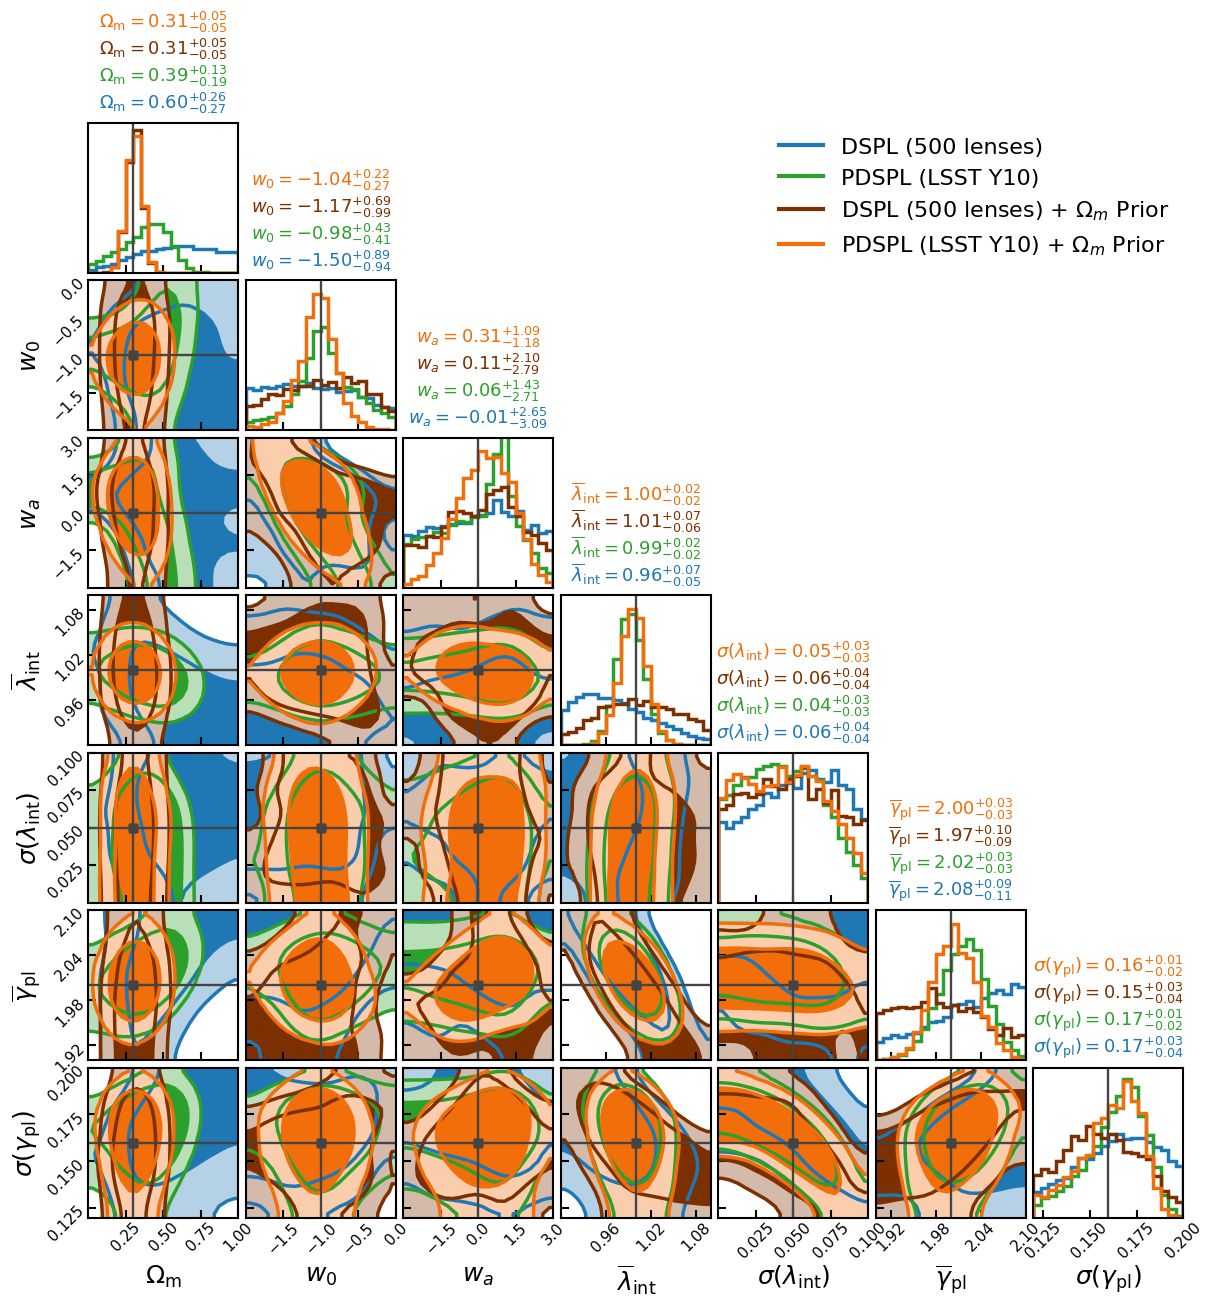

In [ ]:
scenarios_to_plot = [
    'DSPL',
    'lsst_y10',
    'DSPL_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'DSPL': '#1f77b4',
    'lsst_y10': '#2ca02c',
    'DSPL_om_prior': "#7c3000",
    'lsst_y10_om_prior': "#f26e0a"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict,
    save_path=FIGURE_DIRECTORY + "/pdspls_vs_DSPL_w0waCDM_scatter_forecast.pdf"
)

plt.show()

### g. All PDSPLs Corner Plot -- Uniform Priors

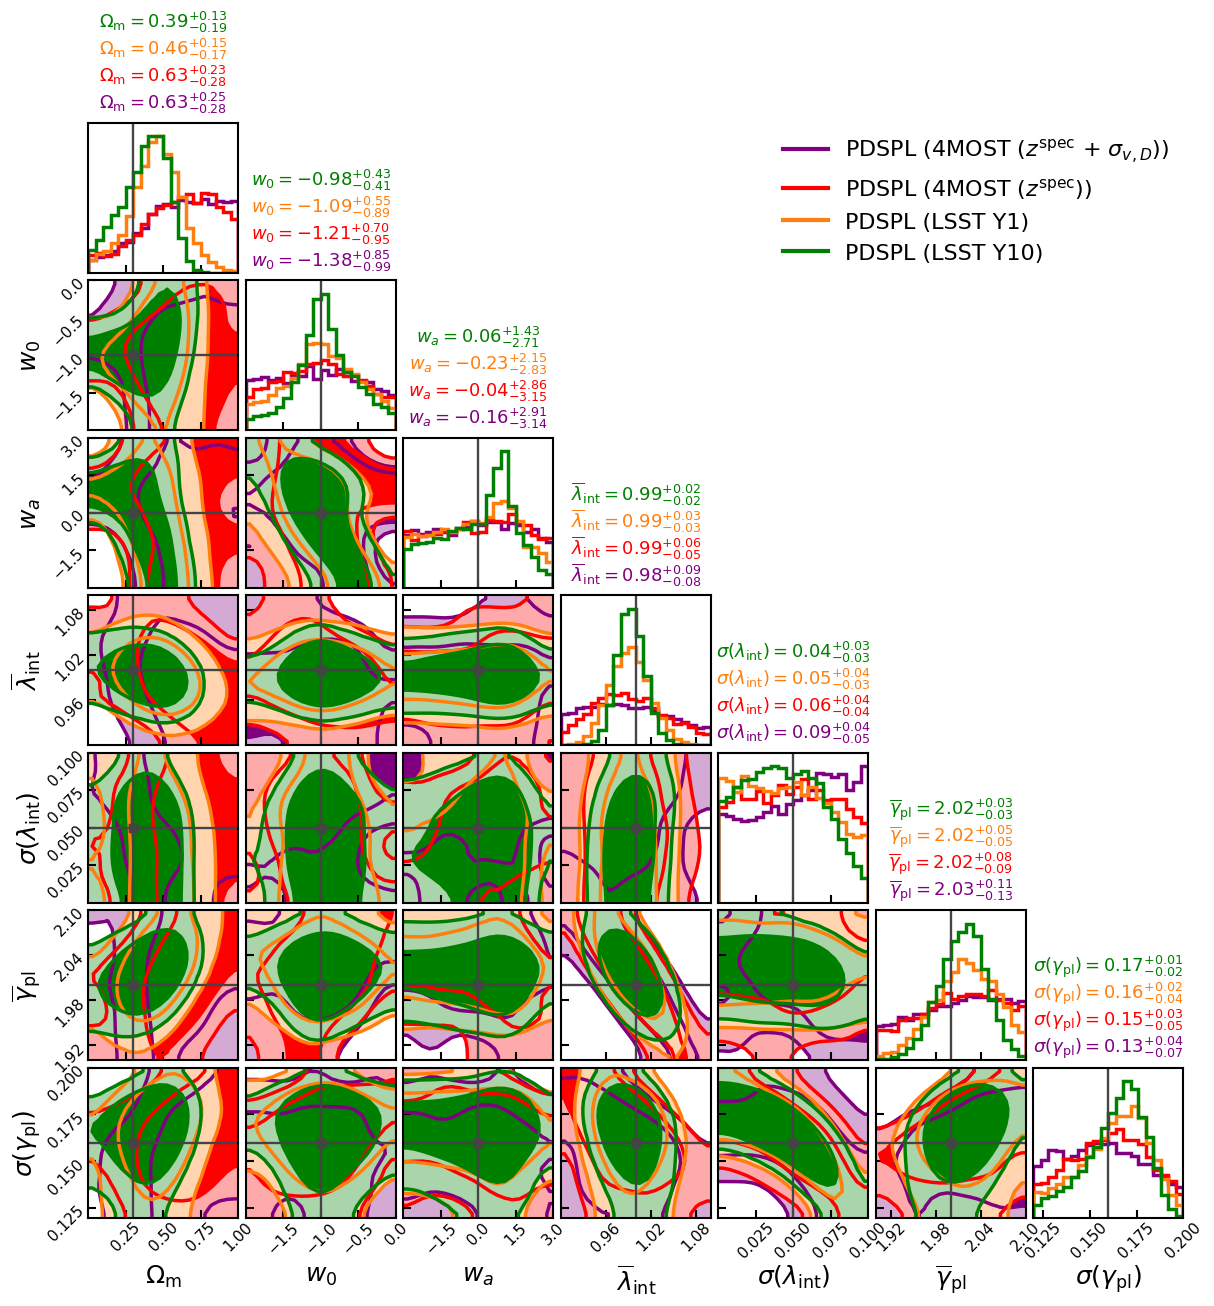

In [ ]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v',
    'lsst_4most_spec-z',
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    save_path=FIGURE_DIRECTORY + "/pdspls_w0waCDM_scatter_forecast.pdf"
)

plt.show()

## Table of All Forecast Results

In [ ]:
# print a latex table of the median and 16th/84th percentiles for each parameter and scenario
print("\n--- Parameter Summary Table (Median with 16th/84th Percentiles) ---")
print(f"{'Scenario':<80} | {'Parameter':<30} | {'Median':<10} | {'-1σ':<10} | {'+1σ':<10}")
print("-" * 150) 
for key in scenarios.keys():
    sc = scenarios[key]
    if 'samples' not in sc:
        continue
    
    samples = sc['samples']
    scenario_name = sc['name']
    
    for param_idx, param_key in enumerate(param_labels):
        samples_1d = samples[:, param_idx]
        q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
        lower_err = q50 - q16
        upper_err = q84 - q50
        
        print(f"{scenario_name:<80} | {param_key:<30} | {q50:<10.3f} | {lower_err:<10.3f} | {upper_err:<10.3f}")

# save the scenarios dictionary with the samples included into a new pickle file for later use
with open('../data/samples/forecast_scenarios_w0waCDM_fixed_scatter.pkl', 'wb') as f:
    pickle.dump(scenarios, f)


--- Parameter Summary Table (Median with 16th/84th Percentiles) ---
Scenario                                                                         | Parameter                      | Median     | -1σ        | +1σ       
------------------------------------------------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                                                  | $\Omega_m$                     | 0.458      | 0.166      | 0.154     
PDSPL (LSST Y1)                                                                  | $w_0$                          | -1.089     | 0.886      | 0.555     
PDSPL (LSST Y1)                                                                  | $w_a$                          | -0.225     | 2.825      | 2.153     
PDSPL (LSST Y1)                                                                  | $\bar{\lambda}_{\rm int}$      | 0.992      | 0.027      | 0.027     
PDSPL (LSST Y1)

## Latex Table of All Forecast Results

In [ ]:
import numpy as np

# --- Helper to format MCMC constraints into LaTeX strings ---
def format_latex_constraint(samples, decimals=2):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    lower_err = q50 - q16
    upper_err = q84 - q50
    
    # If the errors are symmetric within 10%, use \pm
    if abs(upper_err - lower_err) / max(upper_err, lower_err) < 0.1:
        avg_err = (upper_err + lower_err) / 2.0
        return f"${q50:.{decimals}f} \\pm {avg_err:.{decimals}f}$"
    else:
        return f"${q50:.{decimals}f}^{{+{upper_err:.{decimals}f}}}_{{-{lower_err:.{decimals}f}}}$"

# --- Configuration ---
# The order of parameters in your MCMC chains
sampled_params = ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']

# Number of decimal places for each parameter respectively
decimal_places = [2, 2, 2, 3, 3, 3, 3]

# Map your scenario keys to the desired LaTeX display names
latex_row_names = {
    'DSPL': 'DSPL (500 lenses)',
    'lsst_y10': 'PDSPL (LSST Y10)',
    'lsst_4most_spec-z': 'PDSPL (4MOST $z^{\\rm spec}$)',
    'lsst_4most_spec-z_sigma_v': 'PDSPL (4MOST $z^{\\rm spec}$ + $\\sigma_v$)',
    'joint_PDSPL': 'Joint PDSPL',
    'joint_PDSPL_DSPL': 'Joint DSPL + PDSPL'
}

# --- Generate Table ---
print("\\begin{tabular}{l" + "c" * len(sampled_params) + "}")
print("\\toprule")
print("Sample & $\\Omega_{\\rm m}$ & $w_0$ & $w_a$ & $\\overline\\lambda_{\\rm int}$ & $\\sigma(\\lambda_{\\rm int})$ & $\\overline\\gamma_{\\rm pl}$ & $\\sigma(\\gamma_{\\rm pl})$ \\\\")
print("\\midrule")

# 1. Uniform Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    if key in scenarios and 'samples' in scenarios[key]:
        samples = scenarios[key]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\midrule")

# 2. Omega_m Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM + $\\Omega_{m}$ prior$^\\dagger$}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    key_prior = key + '_om_prior'
    if key_prior in scenarios and 'samples' in scenarios[key_prior]:
        samples = scenarios[key_prior]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\bottomrule")
print("\\end{tabular}")

## Experiment 1 - Effect of Photometric Redshift Uncertainties on Forecasts

In [ ]:
# --- 1. INITIALIZE SCENARIOS ---
scenarios_lsst_y10_z_err = {}

for rel_z_error in [0.00, 0.01, 0.02, 0.03, 0.05]:
    key = 'lsst_y10'
    key_long = key + f"_z_error_{rel_z_error:.2f}"
    scenarios_lsst_y10_z_err[key_long] = {
        'name': f"PDSPL ({pdspl_samples[key]['name']})" + f" $\\sigma_z = {rel_z_error:.2f}(1 + z)$",
        'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 200, 
        'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
        'color': pdspl_samples[key]['color'],
        'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
        'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
        'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        'redshift_error_rel': rel_z_error,
        'backend_path': None
    }

# --- 2. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios_lsst_y10_z_err.keys():
    sc = scenarios_lsst_y10_z_err[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []

    pairs_table = sc['pairs_table']
    pairs_table_with_errors = sc['pairs_table_with_errors']
    coeffs = sc['coeffs']
    random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
    
    for i in random_indices:
        z_lens = pairs_table["z_D"][i]
        z1 = pairs_table["z_S1"][i]
        z2 = pairs_table["z_S2"][i]
        
        dissimilarity = pairs_table_with_errors['dissimilarity'][i]
        sigma_beta_intrinsic = np.polyval(coeffs, dissimilarity)
        
        sigma_beta_meas, sigma_beta_los = 0.01, 0.01
        sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_intrinsic=sigma_beta_intrinsic, 
            sigma_meas_rel=sigma_meas_rel,
            dissimilarity=dissimilarity,
            down_sampling=sc['down_sampling'], 
            with_noise=False, # For ASIMOV inference
            cosmo=cosmo_true, 
            redshift_error_rel=sc['redshift_error_rel']
        ))
            
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y10) $\sigma_z = 0.00(1 + z)$                    | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.01(1 + z)$                    | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.02(1 + z)$                    | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.03(1 + z)$                    | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.05(1 + z)$                    | 200        | GENERATED


In [ ]:
# --- 3. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers ---")

for key in scenarios_lsst_y10_z_err.keys():
    sc = scenarios_lsst_y10_z_err[key]
    
    if 'kwargs_list' not in sc: continue
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    coeffs = sc.get('coeffs', [0.0])
    c0, c1, c2 = 0.0, 0.0, 0.0
    if len(coeffs) == 1: c0 = coeffs[0]
    elif len(coeffs) == 2: c1, c0 = coeffs
    elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]
    
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc['beta_c0'] = c0
    fixed_params_sc['beta_c1'] = c1
    fixed_params_sc['beta_c2'] = c2
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers ---

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.00(1 + z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


  4%|▍         | 76/2000 [00:08<02:38, 12.16it/s]

100%|██████████| 2000/2000 [03:30<00:00,  9.50it/s]


PDSPL (LSST Y10) $\sigma_z = 0.00(1 + z)$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.01(1 + z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:31<00:00,  9.47it/s]


...

PDSPL (LSST Y10) $\sigma_z = 0.02(1 + z)$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.03(1 + z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [04:14<00:00,  7.87it/s]


PDSPL (LSST Y10) $\sigma_z = 0.03(1 + z)$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.05(1 + z)$
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [03:33<00:00,  9.37it/s]

PDSPL (LSST Y10) $\sigma_z = 0.05(1 + z)$ | INFERENCE COMPLETE


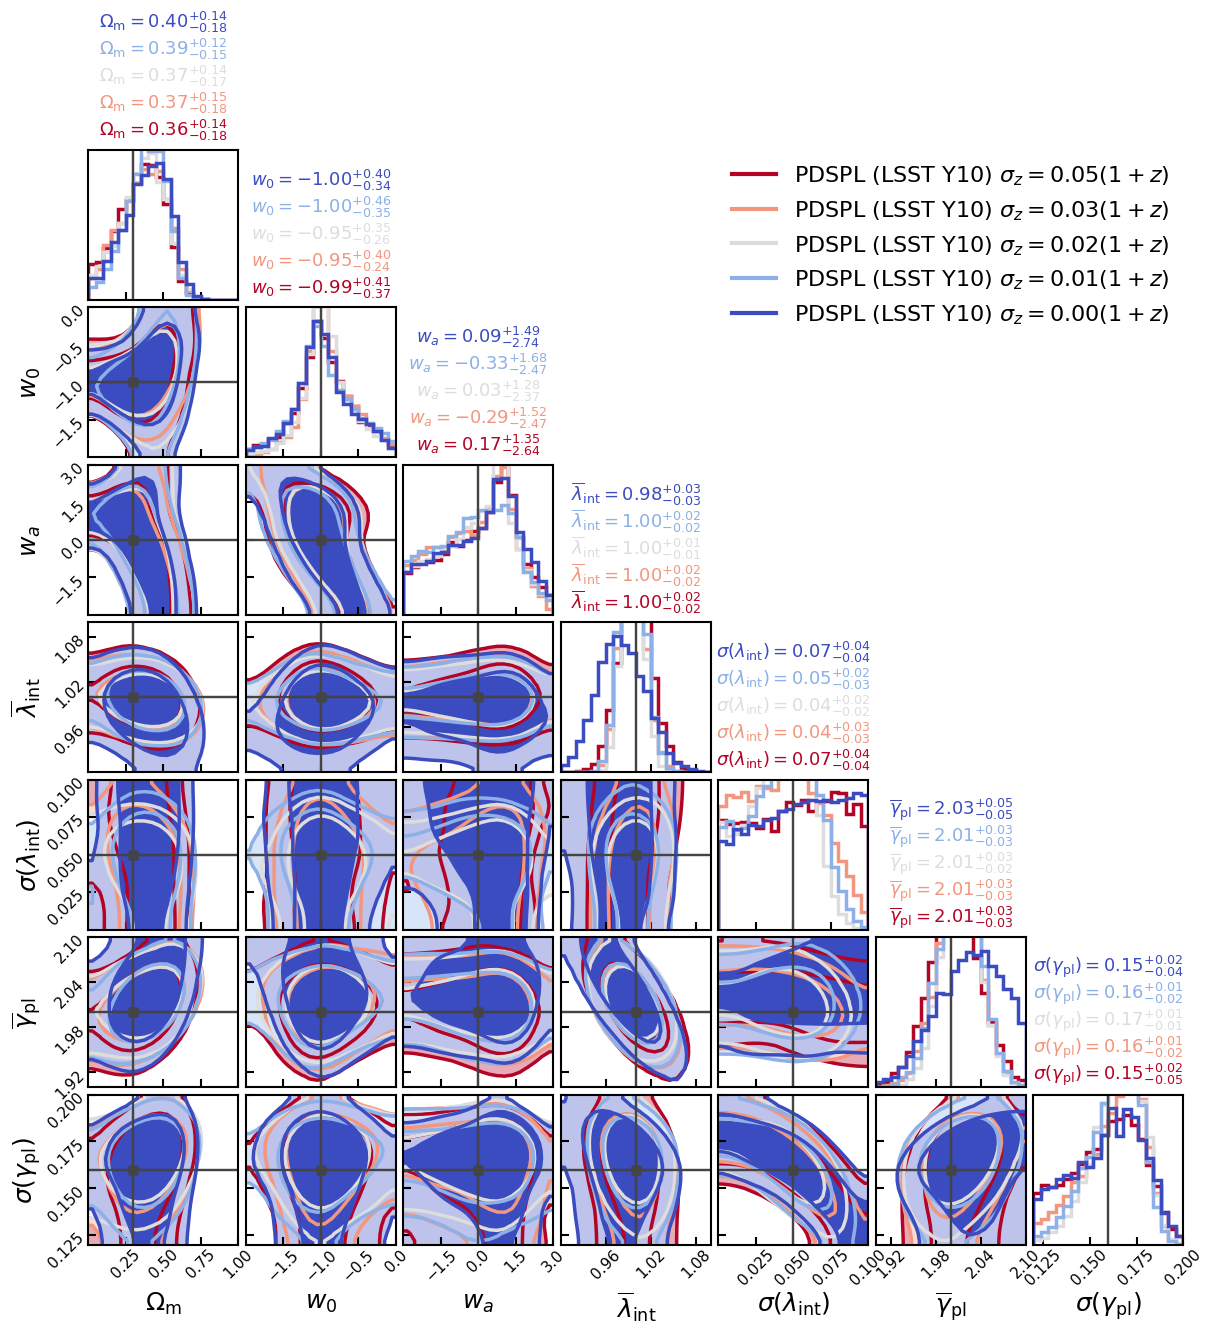

In [ ]:
scenarios_to_plot = [
    'lsst_y10_z_error_0.05',
    'lsst_y10_z_error_0.03',
    'lsst_y10_z_error_0.02',
    'lsst_y10_z_error_0.01',
    'lsst_y10_z_error_0.00',
]

custom_colors_dict = {
    'lsst_y10_z_error_0.00': '#3b4cc0',
    'lsst_y10_z_error_0.01': '#8cb0e7',
    'lsst_y10_z_error_0.02': '#dddddd',
    'lsst_y10_z_error_0.03': '#f2967f',
    'lsst_y10_z_error_0.05': '#b40426',
}

fig = plot_dspl_corner(
    scenarios=scenarios_lsst_y10_z_err, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()